# Resultados iniciales
## Tema 13: Identificación de menciones de entidades biomédicas en resúmenes de investigación

Integrantes:
- José Ricardo Méndez González, 21289
- Sara María Pérez Echeverría, 21371
- Emily Elvia Melissa Pérez Alarcón, 21385
- Adrian Fulladolsa Palma, 21592

In [36]:
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
import pandas as pd
import nltk
import re

### Preprocesamiento

In [37]:
# download necessary nltk resources
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/galaga/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/galaga/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [38]:
# function to clean and preprocess text
def preprocessText(text):
    # convert to lowercase
    text = text.lower()
    
    # remove non-alphabetic characters
    text = re.sub(r'[^a-z\s]', '', text)
    
    # tokenize by spaces
    tokens = text.split()
    
    # remove stopwords
    stopWords = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stopWords]
    
    # lemmatization
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return ' '.join(tokens)

In [39]:
# path of the data
dataPath = '../data/'

# load data
abstractsTrain = pd.read_csv(dataPath + 'abstracts_train.csv', on_bad_lines='skip', delimiter='\t')
entitiesTrain = pd.read_csv(dataPath + 'entities_train.csv', on_bad_lines='skip', delimiter='\t')
relationsTrain = pd.read_csv(dataPath + 'relations_train.csv', on_bad_lines='skip', delimiter='\t')
abstractsTest = pd.read_csv(dataPath + 'abstracts_test.csv', on_bad_lines='skip', delimiter='\t')

In [40]:
# apply the preprocessing function to the abstract text column
abstractsTrain['cleanAbstract'] = abstractsTrain['abstract'].apply(preprocessText)
abstractsTest['cleanAbstract'] = abstractsTest['abstract'].apply(preprocessText)

# show the cleaned texts
print(abstractsTrain[['abstract', 'cleanAbstract']].head())
print(abstractsTest[['abstract', 'cleanAbstract']].head())

                                            abstract  \
0  We report on a new allele at the arylsulfatase...   
1  Classical phenylketonuria is an autosomal rece...   
2  The metabolism of the cardioselective beta-blo...   
3  Previous experiments in this laboratory have s...   
4  Eighty unrelated individuals with Duchenne mus...   

                                       cleanAbstract  
0  report new allele arylsulfatase arsa locus cau...  
1  classical phenylketonuria autosomal recessive ...  
2  metabolism cardioselective betablocker metopro...  
3  previous experiment laboratory shown microinje...  
4  eighty unrelated individual duchenne muscular ...  
                                            abstract  \
0  The effect of induced hypertension instituted ...   
1  A linkage study in 30 Becker muscular dystroph...   
2  The effects of a 6-hour infusion with haloperi...   
3  Fragments of the adrenoleukodystrophy (ALD) cD...   
4  The ability to scan a large gene rapidly and a... 

In [41]:
# group entities by abstract_id
entities_grouped = entitiesTrain.groupby('abstract_id')['type'].apply(list).reset_index()

# merge the cleaned abstracts with their corresponding entities by 'abstract_id'
data_merged = pd.merge(abstractsTrain, entities_grouped, how='inner', on='abstract_id')

### Implementación de modelos

In [42]:
from sklearn.model_selection import train_test_split

# dataset splitting, 80% for training and 20% for testing
X_train_val, X_test, y_train_val, y_test = train_test_split(
    data_merged['cleanAbstract'], data_merged['type'], test_size=0.2, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42  # 0.25 * 0.8 = 0.2 del total
)

# sizes of the splits
print(f'Training set for validation size: {len(X_train_val)}')
print(f'Test set for prediccitions size: {len(X_test)}')
print(f'Training set size: {len(X_train)}')
print(f'Validation set size: {len(X_val)}')

Training set for validation size: 320
Test set for prediccitions size: 80
Training set size: 240
Validation set size: 80


#### Long Short-Term Memory Networks (LSTM)

In [43]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from sklearn.preprocessing import MultiLabelBinarizer

tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)

max_sequence_length = max([len(seq) for seq in X_val_seq])

mlb = MultiLabelBinarizer()
y_train_encoded = mlb.fit_transform(y_train)
y_val_encoded = mlb.transform(y_val)

max_length = max(len(seq) for seq in X_train_seq)
X_train_pad = pad_sequences(X_train_seq, maxlen=max_length, padding='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=max_length, padding='post')

model = Sequential([
    Embedding(input_dim=len(tokenizer.word_index) + 1, output_dim=128, input_length=max_length),
    LSTM(units=128, return_sequences=False),
    Dense(units=len(mlb.classes_), activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.fit(X_train_pad, y_train_encoded, validation_data=(X_val_pad, y_val_encoded), epochs=30, batch_size=32)

Epoch 1/30


/Users/galaga/Documents/Github/Proyecto02-CC3084/myenv/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 188ms/step - accuracy: 0.2412 - loss: 0.6443 - val_accuracy: 0.3375 - val_loss: 0.4572
Epoch 2/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 173ms/step - accuracy: 0.3405 - loss: 0.4657 - val_accuracy: 0.3375 - val_loss: 0.4468
Epoch 3/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 194ms/step - accuracy: 0.3405 - loss: 0.4620 - val_accuracy: 0.3375 - val_loss: 0.4424
Epoch 4/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 175ms/step - accuracy: 0.3405 - loss: 0.4591 - val_accuracy: 0.3375 - val_loss: 0.4414
Epoch 5/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 172ms/step - accuracy: 0.3405 - loss: 0.4574 - val_accuracy: 0.3375 - val_loss: 0.4431
Epoch 6/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 174ms/step - accuracy: 0.3405 - loss: 0.4565 - val_accuracy: 0.3375 - val_loss: 0.4437
Epoch 7/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 174ms/step - accuracy: 0.3405 - loss: 0.4571 - val_accuracy: 0.3375 - val_loss: 0.4427
Epoch 8/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 178ms/step - accuracy: 0.3405 - loss: 0.4567 - val_accuracy: 0.3375 - val_loss: 0.4423
Epo

#### Support Vector Machines (SVM)

In [44]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report

mlb = MultiLabelBinarizer()
y_train_encoded = mlb.fit_transform(y_train)
y_val_encoded = mlb.transform(y_val)

vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)

svm_model = OneVsRestClassifier(SVC(kernel='linear', probability=True))

svm_model.fit(X_train_tfidf, y_train_encoded)

y_pred = svm_model.predict(X_val_tfidf)

print(classification_report(y_val_encoded, y_pred, target_names=mlb.classes_))


                            precision    recall  f1-score   support

                  CellLine       1.00      0.10      0.18        10
            ChemicalEntity       0.75      0.86      0.80        50
DiseaseOrPhenotypicFeature       0.99      1.00      0.99        79
         GeneOrGeneProduct       0.88      0.97      0.92        68
             OrganismTaxon       0.85      1.00      0.92        68
           SequenceVariant       0.92      0.94      0.93        35

                 micro avg       0.88      0.94      0.91       310
                 macro avg       0.90      0.81      0.79       310
              weighted avg       0.89      0.94      0.90       310
               samples avg       0.88      0.94      0.90       310



#### Graph Convolutional Networks (GCN)

In [45]:
import networkx as nx
import numpy as np

G = nx.Graph()

for idx, (abstract, entities) in enumerate(zip(X_train, y_train)):
    for entity in entities:
        unique_entity_id = f"{idx}_{entity}"
        
        G.add_node(unique_entity_id, abstract_id=idx, entity=abstract, x=np.random.rand(128))

for idx, entities in enumerate(y_train):
    for i in range(len(entities)):
        for j in range(i + 1, len(entities)):
            node_id_1 = f"{idx}_{entities[i]}"
            node_id_2 = f"{idx}_{entities[j]}"
            G.add_edge(node_id_1, node_id_2, relation_type="related")

standard_attributes = {'abstract_id': None, 'entity': None}
for node in G.nodes:
    for attr, default_value in standard_attributes.items():
        if attr not in G.nodes[node]:
            G.nodes[node][attr] = default_value


In [46]:
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from torch_geometric.utils import from_networkx
from sklearn.preprocessing import MultiLabelBinarizer
import numpy as np

data = from_networkx(G)

data.x = torch.tensor([G.nodes[node]['x'] for node in G.nodes], dtype=torch.float32)

mlb = MultiLabelBinarizer()
y_encoded = mlb.fit_transform(y_train)  
y_full = np.zeros((data.num_nodes, len(mlb.classes_)))

for idx, entities in enumerate(y_train):
    y_encoded = mlb.transform([entities])[0]
    y_full[idx] = y_encoded

data.y = torch.tensor(y_full, dtype=torch.float32)

class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return x 

modelGCN = GCN(in_channels=128, hidden_channels=16, out_channels=len(mlb.classes_))
optimizer = torch.optim.Adam(modelGCN.parameters(), lr=0.01, weight_decay=5e-4)

def train():
    modelGCN.train()
    optimizer.zero_grad()
    out = modelGCN(data.x, data.edge_index)
    loss = F.binary_cross_entropy_with_logits(out, data.y)
    loss.backward()
    optimizer.step()
    return loss.item()

for epoch in range(500):
    loss = train()
    print(f'Epoch {epoch}: Loss {loss:.4f}')


Epoch 0: Loss 0.6883
Epoch 1: Loss 0.5927
Epoch 2: Loss 0.5408
Epoch 3: Loss 0.5152
Epoch 4: Loss 0.4950
Epoch 5: Loss 0.4777
Epoch 6: Loss 0.4636
Epoch 7: Loss 0.4534
Epoch 8: Loss 0.4449
Epoch 9: Loss 0.4381
Epoch 10: Loss 0.4332
Epoch 11: Loss 0.4291
Epoch 12: Loss 0.4277
Epoch 13: Loss 0.4303
Epoch 14: Loss 0.4340
Epoch 15: Loss 0.4355
Epoch 16: Loss 0.4343
Epoch 17: Loss 0.4315
Epoch 18: Loss 0.4285
Epoch 19: Loss 0.4260
Epoch 20: Loss 0.4240
Epoch 21: Loss 0.4223
Epoch 22: Loss 0.4207
Epoch 23: Loss 0.4190
Epoch 24: Loss 0.4176
Epoch 25: Loss 0.4166
Epoch 26: Loss 0.4158
Epoch 27: Loss 0.4149
Epoch 28: Loss 0.4139
Epoch 29: Loss 0.4128
Epoch 30: Loss 0.4116
Epoch 31: Loss 0.4103
Epoch 32: Loss 0.4092
Epoch 33: Loss 0.4083
Epoch 34: Loss 0.4076
Epoch 35: Loss 0.4066
Epoch 36: Loss 0.4053
Epoch 37: Loss 0.4040
Epoch 38: Loss 0.4028
Epoch 39: Loss 0.4016
Epoch 40: Loss 0.4006
Epoch 41: Loss 0.3993
Epoch 42: Loss 0.3980
Epoch 43: Loss 0.3965
Epoch 44: Loss 0.3950
Epoch 45: Loss 0.393

#### Bidirectional Encoder Representations from Transformers (BERT)

In [47]:
from transformers import BertTokenizer, BertForSequenceClassification
num_classes = 6
tokenizerBert = BertTokenizer.from_pretrained("bert-base-uncased")
modelBERT = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=num_classes)

mlb = MultiLabelBinarizer()
y_train_encoded = mlb.fit_transform(y_train)
y_val_encoded = mlb.transform(y_val)

def preprocess_texts_BERT(texts, labels):
    inputs = tokenizerBert(
        texts, padding=True, truncation=True, max_length=128, return_tensors="pt"
    )
    inputs["labels"] = torch.tensor(labels, dtype=torch.float)
    return inputs

train_texts = list(X_train)
train_labels = y_train_encoded
train_data = preprocess_texts_BERT(train_texts, train_labels)

val_texts = list(X_val)
val_labels = y_val_encoded
val_data = preprocess_texts_BERT(val_texts, val_labels)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [48]:
from torch.utils.data import Dataset

class TextDataset(Dataset):
    def __init__(self, encodings):
        self.encodings = encodings

    def __len__(self):
        return len(self.encodings["input_ids"])

    def __getitem__(self, idx):
        return {key: tensor[idx] for key, tensor in self.encodings.items()}

train_dataset = TextDataset(train_data)
val_dataset = TextDataset(val_data)

In [49]:
import os

os.environ["TRANSFORMERS_NO_TF"] = "1"
from transformers import Trainer, TrainingArguments


training_args = TrainingArguments(
    output_dir="./results",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=10,
    load_best_model_at_end=True,
)

trainer = Trainer(
    model=modelBERT,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
)

trainer.train()


/Users/galaga/Documents/Github/Proyecto02-CC3084/myenv/lib/python3.11/site-packages/transformers/training_args.py:1559: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
 11%|█         | 10/90 [00:02<00:19,  4.10it/s]

{'loss': 0.6728, 'grad_norm': 2.51310658454895, 'learning_rate': 1.0000000000000002e-06, 'epoch': 0.33}


 22%|██▏       | 20/90 [00:04<00:16,  4.14it/s]

{'loss': 0.6616, 'grad_norm': 2.1498167514801025, 'learning_rate': 2.0000000000000003e-06, 'epoch': 0.67}


 33%|███▎      | 30/90 [00:07<00:14,  4.08it/s]

...


100%|██████████| 90/90 [00:29<00:00,  4.06it/s]

{'eval_loss': 0.44286197423934937, 'eval_runtime': 0.6224, 'eval_samples_per_second': 128.543, 'eval_steps_per_second': 16.068, 'epoch': 3.0}


100%|██████████| 90/90 [00:32<00:00,  2.80it/s]

{'train_runtime': 32.1241, 'train_samples_per_second': 22.413, 'train_steps_per_second': 2.802, 'train_loss': 0.566173521677653, 'epoch': 3.0}


TrainOutput(global_step=90, training_loss=0.566173521677653, metrics={'train_runtime': 32.1241, 'train_samples_per_second': 22.413, 'train_steps_per_second': 2.802, 'total_flos': 47361690869760.0, 'train_loss': 0.566173521677653, 'epoch': 3.0})

In [50]:
def preprocess_text_for_prediction(text):
    inputs = tokenizerBert(
        text, padding=True, truncation=True, max_length=128, return_tensors="pt"
    )
    return inputs["input_ids"], inputs["attention_mask"]

### Predicciones

In [51]:
import re

def extract_entity_ids(abstract):
    matched_entity_ids = []
    tokens = re.findall(r'\w+', abstract.lower())

    for node_id, node_data in G.nodes(data=True):
        entity_text = node_data.get('entity', '')
        if entity_text:
            entity_tokens = set(re.findall(r'\w+', entity_text.lower()))
            if entity_tokens.intersection(tokens):  
                matched_entity_ids.append(node_id)
    return matched_entity_ids

In [52]:
def predict_entities_lstm(abstract):
    sequence = tokenizer.texts_to_sequences([abstract])
    padded_sequence = pad_sequences(sequence, maxlen=max_sequence_length)
    prediction = model.predict(padded_sequence)
    predicted_entities = mlb.inverse_transform(prediction > 0.5)
    return predicted_entities[0]  

def predict_entities_svm(abstract):
    tfidf_sequence = vectorizer.transform([abstract])
    prediction = svm_model.predict(tfidf_sequence)
    predicted_entities = mlb.inverse_transform(prediction)
    return predicted_entities[0] 

def predict_entities_gcn(abstract):
    entity_ids = extract_entity_ids(abstract)
    subgraph_nx = G.subgraph(entity_ids)
    subgraph_data = from_networkx(subgraph_nx)
    if subgraph_data.x is not None and subgraph_data.x.numel() > 0:
        subgraph_data.x = subgraph_data.x.float()
        
        modelGCN.eval()
        with torch.no_grad():
            out = modelGCN(subgraph_data.x, subgraph_data.edge_index)
        
        predicted_classes = (out > 0.5).cpu().numpy()
        predicted_entities = mlb.inverse_transform(predicted_classes)
        return predicted_entities[0]
    return ()

def predict_entities_bert(abstract):
    device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
    
    input_ids, attention_mask = preprocess_text_for_prediction(abstract)
    input_ids = input_ids.to(device)
    attention_mask = attention_mask.to(device)
    
    modelBERT.to(device)
    modelBERT.eval()
    with torch.no_grad():
        outputs = modelBERT(input_ids, attention_mask=attention_mask)
    
    predicted_classes = (outputs.logits > 0.5).cpu().numpy()
    predicted_entities = mlb.inverse_transform(predicted_classes)
    
    return predicted_entities[0] 

In [53]:
abstract_example = "metachromatic"
print("LSTM Prediction:", predict_entities_lstm(abstract_example))
print("SVM Prediction:", predict_entities_svm(abstract_example))
print("GCN Prediction:", predict_entities_gcn(abstract_example))
print("BERT Prediction:", predict_entities_bert(abstract_example))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
LSTM Prediction: ('ChemicalEntity', 'DiseaseOrPhenotypicFeature', 'GeneOrGeneProduct', 'OrganismTaxon')
SVM Prediction: ('ChemicalEntity', 'DiseaseOrPhenotypicFeature', 'GeneOrGeneProduct', 'OrganismTaxon')
GCN Prediction: ()
BERT Prediction: ('DiseaseOrPhenotypicFeature', 'GeneOrGeneProduct')


### Evaluación de los modelos

In [61]:
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score

In [59]:
def get_model_predictions(abstracts, model_predict_function):
    predictions = []
    for abstract in abstracts:
        predicted_entities = model_predict_function(abstract)
        predictions.append(predicted_entities)
    return predictions

# Obtener predicciones reales de cada modelo
y_pred_lstm = get_model_predictions(X_test, predict_entities_lstm)
y_pred_svm = get_model_predictions(X_test, predict_entities_svm)
y_pred_gcn = get_model_predictions(X_test, predict_entities_gcn)
y_pred_bert = get_model_predictions(X_test, predict_entities_bert)

# Función para calcular métricas para cada modelo


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━

In [63]:
def calculate_model_metrics(y_true, y_pred, model_name):
    # Convertir `y_true` y `y_pred` a formato binario
    mlb = MultiLabelBinarizer()
    y_true_bin = mlb.fit_transform(y_true)
    y_pred_bin = mlb.transform(y_pred)

    # Calcular las métricas con el formato binario
    f1 = f1_score(y_true_bin, y_pred_bin, average='micro')
    seq_label_accuracy = accuracy_score(y_true_bin, y_pred_bin)
    roc_auc = roc_auc_score(y_true_bin, y_pred_bin, average="micro")
    
    return {"Model": model_name, "F1 Score (Micro)": f1, "Sequence Label Accuracy": seq_label_accuracy, "ROC-AUC": roc_auc}

In [64]:
# Calcular métricas para cada modelo
metrics = [
    calculate_model_metrics(y_test, y_pred_lstm, "LSTM"),
    calculate_model_metrics(y_test, y_pred_svm, "SVM"),
    calculate_model_metrics(y_test, y_pred_gcn, "GCN"),
    calculate_model_metrics(y_test, y_pred_bert, "BERT")
]

# Mostrar métricas
metrics_df = pd.DataFrame(metrics)
print(metrics_df)

  Model  F1 Score (Micro)  Sequence Label Accuracy   ROC-AUC
0  LSTM          0.848967                   0.2125  0.777068
1   SVM          0.901716                   0.3875  0.841907
2   GCN          0.627119                   0.0125  0.695623
3  BERT          0.841060                   0.2250  0.791120


### Visualización de resultados

In [68]:
%pip install seaborn

/Users/galaga/.zshenv:export:1: not valid in this context: Support/JetBrains/Toolbox/scripts
  Obtaining dependency information for seaborn from https://files.pythonhosted.org/packages/83/11/00d3c3dfc25ad54e731d91449895a79e4bf2384dc3ac01809010ba88f6d5/seaborn-0.13.2-py3-none-any.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 2.2 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 23.2.1 -> 24.3.1
[notice] To update, run: /Users/galaga/Documents/Github/Proyecto02-CC3084/myenv/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [80]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, confusion_matrix

# 1. Gráfico de barras para comparar las métricas de cada modelo
def plot_model_metrics(metrics_df):
    metrics_df.set_index('Model', inplace=True)
    metrics_df.plot(kind='bar', figsize=(10, 6))
    plt.title('Comparación de Métricas entre Modelos')
    plt.xlabel('Modelos')
    plt.ylabel('Puntuación')
    plt.legend(loc='upper right')
    plt.xticks(rotation=45)
    plt.show()

# 2. Curvas ROC de cada modelo
def plot_roc_curves(y_true, y_preds, model_names):
    # Convertir `y_true` y cada `y_pred` a formato binario
    mlb = MultiLabelBinarizer()
    y_true_bin = mlb.fit_transform(y_true)
    y_preds_bin = [mlb.transform(y_pred) for y_pred in y_preds]

    # Crear la gráfica ROC
    plt.figure(figsize=(10, 8))
    for y_pred_bin, model_name in zip(y_preds_bin, model_names):
        fpr, tpr, _ = roc_curve(y_true_bin.ravel(), y_pred_bin.ravel())
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.2f})')
    
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Tasa de Falsos Positivos')
    plt.ylabel('Tasa de Verdaderos Positivos')
    plt.title('Curvas ROC de cada Modelo')
    plt.legend(loc='lower right')
    plt.show()

# 3. Matriz de Confusión para cada modelo
labels = ['DiseaseOrPhenotypicFeature', 'GeneOrGeneProduct', 'ChemicalEntity', 'OrganismTaxon']
def plot_confusion_matrix(y_true, y_pred, model_name, labels=labels):
    # Convertir y_true y y_pred a formato binario si aún no lo están
    mlb = MultiLabelBinarizer(classes=labels)
    y_true_bin = mlb.fit_transform(y_true)
    y_pred_bin = mlb.transform(y_pred)
    
    # Calcular la matriz de confusión para cada etiqueta individualmente
    cm = confusion_matrix(y_true_bin.ravel(), y_pred_bin.ravel())
    
    # Crear el heatmap de la matriz de confusión
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
                xticklabels=["No", "Sí"], yticklabels=["No", "Sí"])
    plt.title(f'Matriz de Confusión - {model_name}')
    plt.xlabel('Etiqueta Predicha')
    plt.ylabel('Etiqueta Verdadera')
    plt.show()

In [74]:
y_test

209    [GeneOrGeneProduct, GeneOrGeneProduct, Disease...
280    [GeneOrGeneProduct, OrganismTaxon, DiseaseOrPh...
33     [ChemicalEntity, ChemicalEntity, GeneOrGenePro...
210    [OrganismTaxon, DiseaseOrPhenotypicFeature, Di...
93     [GeneOrGeneProduct, DiseaseOrPhenotypicFeature...
                             ...                        
246    [DiseaseOrPhenotypicFeature, GeneOrGeneProduct...
227    [ChemicalEntity, DiseaseOrPhenotypicFeature, O...
369    [GeneOrGeneProduct, GeneOrGeneProduct, Disease...
176    [ChemicalEntity, ChemicalEntity, DiseaseOrPhen...
289    [GeneOrGeneProduct, OrganismTaxon, DiseaseOrPh...
Name: type, Length: 80, dtype: object

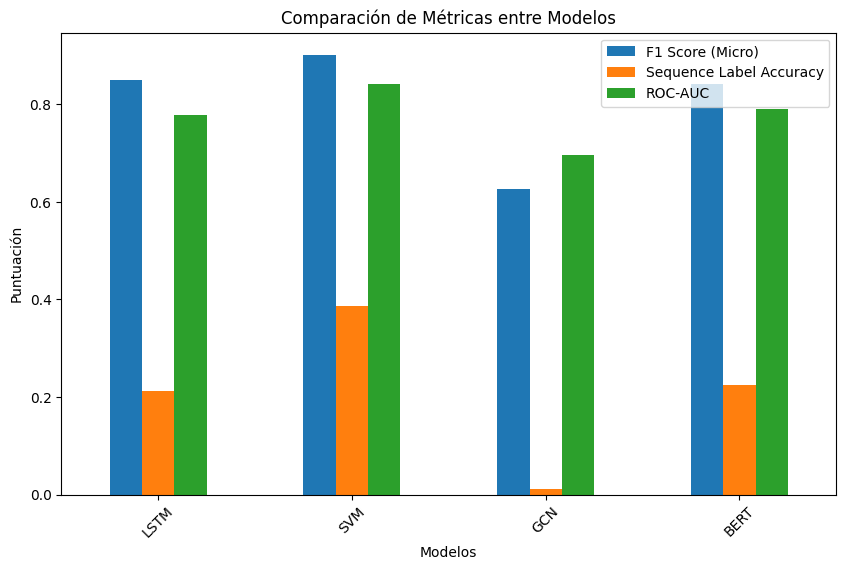

In [70]:
# 1. Gráfico de métricas
plot_model_metrics(metrics_df)

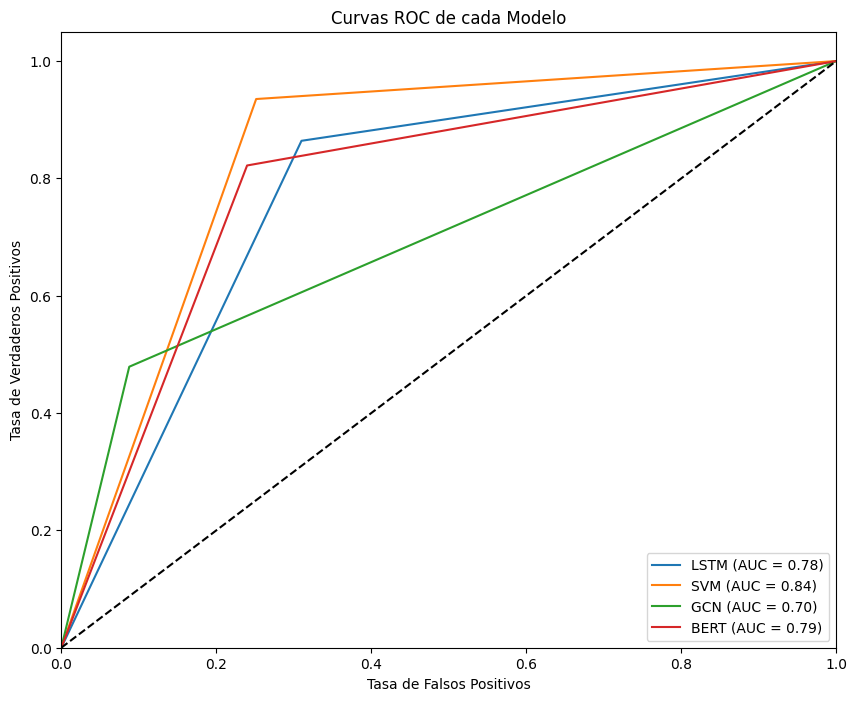

In [76]:
# 2. Curvas ROC para cada modelo
y_preds = [y_pred_lstm, y_pred_svm, y_pred_gcn, y_pred_bert]
model_names = ['LSTM', 'SVM', 'GCN', 'BERT']
plot_roc_curves(y_test, y_preds, model_names)

/Users/galaga/Documents/Github/Proyecto02-CC3084/myenv/lib/python3.11/site-packages/sklearn/preprocessing/_label.py:900: UserWarning: unknown class(es) ['CellLine', 'SequenceVariant'] will be ignored
  warnings.warn(


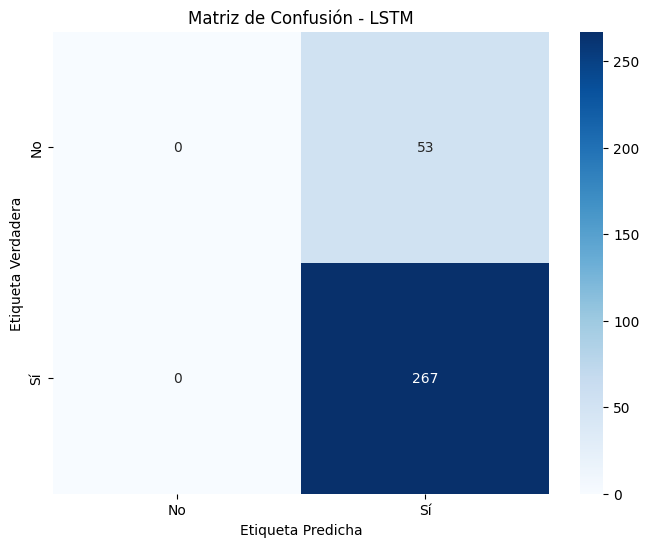

/Users/galaga/Documents/Github/Proyecto02-CC3084/myenv/lib/python3.11/site-packages/sklearn/preprocessing/_label.py:900: UserWarning: unknown class(es) ['CellLine', 'SequenceVariant'] will be ignored
  warnings.warn(


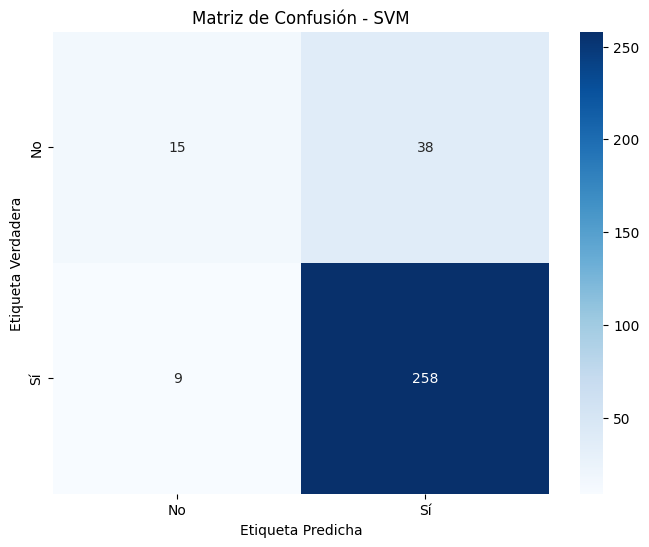

/Users/galaga/Documents/Github/Proyecto02-CC3084/myenv/lib/python3.11/site-packages/sklearn/preprocessing/_label.py:900: UserWarning: unknown class(es) ['CellLine', 'SequenceVariant'] will be ignored
  warnings.warn(


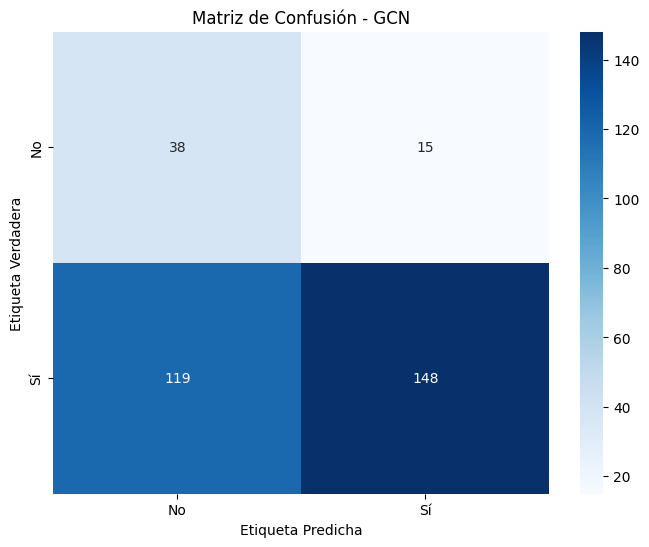

/Users/galaga/Documents/Github/Proyecto02-CC3084/myenv/lib/python3.11/site-packages/sklearn/preprocessing/_label.py:900: UserWarning: unknown class(es) ['CellLine', 'SequenceVariant'] will be ignored
  warnings.warn(


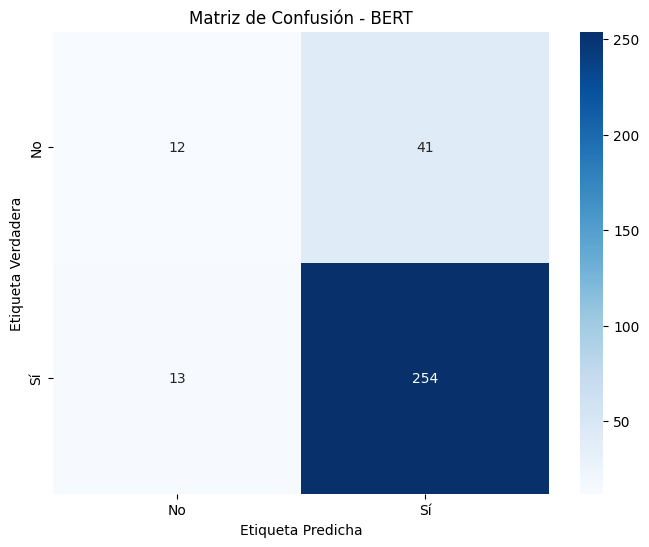

In [81]:
# 3. Matriz de Confusión para cada modelo
for y_pred, model_name in zip([y_pred_lstm, y_pred_svm, y_pred_gcn, y_pred_bert], ['LSTM', 'SVM', 'GCN', 'BERT']):
    plot_confusion_matrix(y_test, y_pred, model_name)